In [1]:
from pathlib import Path
import pandas as pd
import os

path = os.path.join(os.getcwd(), "..", "..", "singapore_weather_monthly")

root = Path(path)


In [3]:
root

WindowsPath('c:/Computer Science/Hackathons/huawei/naisc-2025/model/flood/../../singapore_weather_monthly')

In [4]:

# the full schema you expect
EXPECTED_COLS = [
    "timestamp",
    "temperature",
    "rainfall",
    "humidity",
    "wind_direction",
    "wind_speed",
]

station_parts = {}

for month_dir in sorted(root.iterdir()):
    if not month_dir.is_dir():
        continue

    for csv_path in month_dir.glob("*.csv"):
        station = csv_path.stem

        # try reading with header; fall back to no-header
        try:
            df = pd.read_csv(csv_path, parse_dates=["timestamp"])
        except ValueError:
            df = pd.read_csv(
                csv_path,
                header=None,
                names=EXPECTED_COLS,
                parse_dates=[0],
            )

        # normalize column names
        df.columns = [c.lower() for c in df.columns]

        # ensure *all* expected columns are present, filling missing ones with <NA>
        df = df.reindex(
            columns=EXPECTED_COLS,
            fill_value=pd.NA,
        )

        # set timestamp index
        df["timestamp"] = pd.to_datetime(df["timestamp"])
        df = df.set_index("timestamp").sort_index()

        station_parts.setdefault(station, []).append(df)

# concatenate per-station
for station, parts in station_parts.items():
    full = pd.concat(parts)
    full = full[~full.index.duplicated()]  # drop any true duplicates
    full = full.sort_index()

    # save or keep in memory
    full.to_csv(f"{station}_all_timeseries.csv")
    station_parts[station] = full


C:\Users\Parvez\AppData\Local\Temp\ipykernel_5688\1417172302.py:24: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df = pd.read_csv(
C:\Users\Parvez\AppData\Local\Temp\ipykernel_5688\1417172302.py:41: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df["timestamp"] = pd.to_datetime(df["timestamp"])


DateParseError: Unknown datetime string format, unable to parse: S109, at position 1

In [5]:
import os
import glob
import pandas as pd

# 1. Define folder and file pattern
data_folder = os.path.join(os.getcwd(), "..", "..", "singapore_weather_combined") # adjust if needed
csv_pattern = os.path.join(data_folder, '*.csv')

# 2. Define full hourly datetime index
start = '2024-01-01 00:00:00'
end = '2025-04-26 23:00:00'
full_index = pd.date_range(start=start, end=end, freq='H')

# 3. Required columns
required_cols = ['timestamp', 'temperature', 'rainfall', 'humidity', 'wind_direction', 'wind_speed']

# 4. Process each CSV
for filepath in glob.glob(csv_pattern):
    filename = os.path.basename(filepath)
    # Skip metadata or non-station files if necessary
    if filename == 'combined_station_metadata.csv':
        continue

    # Read original CSV
    df = pd.read_csv(filepath, parse_dates=['timestamp'])

    # Ensure timestamp column exists
    if 'timestamp' not in df.columns:
        continue  # or handle appropriately

    # Set timestamp as index
    df = df.set_index('timestamp')

    # Reindex to full hourly range
    df = df.reindex(full_index)

    # Reset index to column
    df = df.reset_index().rename(columns={'index': 'timestamp'})

    # Ensure all required columns exist
    for col in required_cols:
        if col not in df.columns:
            df[col] = pd.NA

    # Reorder columns
    df = df[required_cols]

    # Save standardized CSV
    out_path = os.path.join(data_folder, 'standardized_' + filename)
    df.to_csv(out_path, index=False)

    print(f'Standardized {filename} -> standardized_{filename}')


C:\Users\Parvez\AppData\Local\Temp\ipykernel_5688\3862270781.py:12: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  full_index = pd.date_range(start=start, end=end, freq='H')


Standardized idw_imputed_standardized_imputed_standardized_S06_Paya_Lebar.csv -> standardized_idw_imputed_standardized_imputed_standardized_S06_Paya_Lebar.csv
Standardized idw_imputed_standardized_imputed_standardized_S07_Lornie_Road.csv -> standardized_idw_imputed_standardized_imputed_standardized_S07_Lornie_Road.csv
Standardized idw_imputed_standardized_imputed_standardized_S08_Upper_Thomson_Road.csv -> standardized_idw_imputed_standardized_imputed_standardized_S08_Upper_Thomson_Road.csv
Standardized idw_imputed_standardized_imputed_standardized_S102_Semakau_Landfill.csv -> standardized_idw_imputed_standardized_imputed_standardized_S102_Semakau_Landfill.csv
Standardized idw_imputed_standardized_imputed_standardized_S104_Woodlands_Avenue_9.csv -> standardized_idw_imputed_standardized_imputed_standardized_S104_Woodlands_Avenue_9.csv
Standardized idw_imputed_standardized_imputed_standardized_S106_Pulau_Ubin.csv -> standardized_idw_imputed_standardized_imputed_standardized_S106_Pulau_Ubi

KeyboardInterrupt: 

In [ ]:
import os
import glob
import pandas as pd

# Folder containing standardized CSVs
data_folder = os.path.join(os.getcwd(), "..", "..", "singapore_weather_combined")
pattern = os.path.join(data_folder, 'standardized_*.csv')

# Process each standardized CSV
for filepath in glob.glob(pattern):
    filename = os.path.basename(filepath)
    print(f'Processing {filename}...')

    # Read CSV and parse timestamp
    df = pd.read_csv(filepath, parse_dates=['timestamp'])
    
    # Set timestamp as index
    df = df.set_index('timestamp').sort_index()
    
    # Perform linear interpolation for gaps <= 3 hours
    # limit=3 ensures only runs of NaNs of length up to 3 are filled
    df_interpolated = df.interpolate(
        method='time',
        limit=3,
        limit_direction='both'
    )
    
    # Write output
    out_path = os.path.join(data_folder, 'imputed_' + filename)
    df_interpolated.reset_index().to_csv(out_path, index=False)
    
    print(f'  Saved imputed data to {os.path.basename(out_path)}')


Processing standardized_S06_Paya_Lebar.csv...
  Saved imputed data to imputed_standardized_S06_Paya_Lebar.csv
Processing standardized_S07_Lornie_Road.csv...
  Saved imputed data to imputed_standardized_S07_Lornie_Road.csv
Processing standardized_S08_Upper_Thomson_Road.csv...
  Saved imputed data to imputed_standardized_S08_Upper_Thomson_Road.csv
Processing standardized_S102_Semakau_Landfill.csv...
  Saved imputed data to imputed_standardized_S102_Semakau_Landfill.csv
Processing standardized_S104_Woodlands_Avenue_9.csv...
  Saved imputed data to imputed_standardized_S104_Woodlands_Avenue_9.csv
Processing standardized_S106_Pulau_Ubin.csv...
  Saved imputed data to imputed_standardized_S106_Pulau_Ubin.csv
Processing standardized_S107_East_Coast_Parkway.csv...
  Saved imputed data to imputed_standardized_S107_East_Coast_Parkway.csv
Processing standardized_S108_Marina_Gardens_Drive.csv...
  Saved imputed data to imputed_standardized_S108_Marina_Gardens_Drive.csv
Processing standardized_S109

In [ ]:
import os
import glob
import pandas as pd
import numpy as np
from math import radians, sin, cos, sqrt, atan2

# 1. Load station metadata
meta_path = os.path.join(os.getcwd(), "..", "..", "singapore_weather_combined", "combined_station_metadata.csv")
meta_df = pd.read_csv(meta_path)
meta_df = meta_df.set_index('id')[['latitude', 'longitude']]

station_ids = meta_df.index.tolist()
coords = meta_df.to_dict('index')  # {id: {'latitude':..., 'longitude':...}, ...}

# 2. Compute pairwise distances (meters) via Haversine
def haversine(lat1, lon1, lat2, lon2):
    R = 6371000  # Earth radius in meters
    phi1, phi2 = radians(lat1), radians(lat2)
    dphi = radians(lat2 - lat1)
    dlambda = radians(lon2 - lon1)
    a = sin(dphi/2)**2 + cos(phi1)*cos(phi2)*sin(dlambda/2)**2
    return 2 * R * atan2(sqrt(a), sqrt(1 - a))

# Build distance map: {id: [(neighbor_id, distance), ...]}
distance_map = {}
for sid in station_ids:
    lat1, lon1 = coords[sid]['latitude'], coords[sid]['longitude']
    distances = [(other, haversine(lat1, lon1, coords[other]['latitude'], coords[other]['longitude']))
                 for other in station_ids if other != sid]
    # Sort ascending by distance
    distance_map[sid] = sorted(distances, key=lambda x: x[1])

# 3. IDW parameters
n_neighbors = 5  # use 5 nearest available stations
power = 2        # inverse-distance-squared weighting

# 4. Process each station CSV for IDW-based imputation
data_folder = os.path.join(os.getcwd(), "..", "..", "singapore_weather_combined")
pattern = os.path.join(data_folder, 'imputed_standardized_*.csv')
features = ['temperature', 'rainfall', 'humidity', 'wind_direction', 'wind_speed']
# Before your IDW loop, build station_dfs like this:
station_dfs = {}
for path in glob.glob('imputed_standardized_S*_*.csv'):
    df = pd.read_csv(path, parse_dates=['timestamp']).set_index('timestamp')
    sid = os.path.basename(path).split('_')[2]  # e.g. 'S109'
    station_dfs[sid] = df

# Now station_dfs['S109'] is the DataFrame for station S109,
# station_dfs['S117'] is for S117, etc.


for filepath in glob.glob(pattern):
    df = pd.read_csv(filepath, parse_dates=['timestamp']).set_index('timestamp')
    sid = os.path.basename(filepath).split('_')[2]  # extract Sxx from filename
    neighbors = distance_map[sid]

    print(f'Imputing for station {sid}...')

    # For each feature and each missing timestamp, perform IDW from neighbors
    for feat in features:
        missing = df[df[feat].isna()].index
        print(f'  Missing timestamps for {feat}: {len(missing)}')
        for t in missing:
            vals, dists = [], []
            # find up to n_neighbors with valid data at time t
            for neighbor_id, dist in neighbors:
                if len(vals) >= n_neighbors:
                    break
                v = station_dfs.get(neighbor_id, pd.DataFrame()).get(feat)
                # Need to load neighbor df once
                if v is None:
                    # lazy-load neighbor df
                    neighbor_file = glob.glob(os.path.join(data_folder, f'imputed_standardized_{neighbor_id}_*.csv'))
                    if neighbor_file:
                        station_dfs[neighbor_id] = pd.read_csv(neighbor_file[0], parse_dates=['timestamp']).set_index('timestamp')
                        v_series = station_dfs[neighbor_id][feat] if feat in station_dfs[neighbor_id] else None
                    else:
                        v_series = None
                else:
                    v_series = v
                if v_series is not None and not pd.isna(v_series.get(t, np.nan)):
                    vals.append(v_series[t])
                    dists.append(dist)
            # Compute IDW if any neighbor values found
            if vals:
                weights = np.array([1/(d**power) for d in dists])
                df.at[t, feat] = np.sum(weights * vals) / np.sum(weights)
    # Save back the imputed file
    out_path = os.path.join(data_folder, 'idw_imputed_standardized_' + os.path.basename(filepath))
    df.reset_index().to_csv(out_path, index=False)
    print(f'  -> Saved {out_path}')


Imputing for station S06...
  -> Saved c:\Computer Science\Hackathons\huawei\naisc-2025\model\flood\..\..\singapore_weather_combined\idw_imputed_standardized_imputed_standardized_S06_Paya_Lebar.csv
Imputing for station S07...
  -> Saved c:\Computer Science\Hackathons\huawei\naisc-2025\model\flood\..\..\singapore_weather_combined\idw_imputed_standardized_imputed_standardized_S07_Lornie_Road.csv
Imputing for station S08...
  -> Saved c:\Computer Science\Hackathons\huawei\naisc-2025\model\flood\..\..\singapore_weather_combined\idw_imputed_standardized_imputed_standardized_S08_Upper_Thomson_Road.csv
Imputing for station S102...
  -> Saved c:\Computer Science\Hackathons\huawei\naisc-2025\model\flood\..\..\singapore_weather_combined\idw_imputed_standardized_imputed_standardized_S102_Semakau_Landfill.csv
Imputing for station S104...
  -> Saved c:\Computer Science\Hackathons\huawei\naisc-2025\model\flood\..\..\singapore_weather_combined\idw_imputed_standardized_imputed_standardized_S104_Woodla

KeyboardInterrupt: 

Change wind speed and dir to direction

In [3]:
import os
data_folder = os.path.join(os.getcwd(), "..", "..", "singapore_weather_combined")

In [4]:
import glob
import numpy as np
import pandas as pd
from math import radians, sin, cos, sqrt, atan2
# 2. Compute pairwise distances (meters) via Haversine
def haversine(lat1, lon1, lat2, lon2):
    R = 6371000  # Earth radius in meters
    phi1, phi2 = radians(lat1), radians(lat2)
    dphi = radians(lat2 - lat1)
    dlambda = radians(lon2 - lon1)
    a = sin(dphi/2)**2 + cos(phi1)*cos(phi2)*sin(dlambda/2)**2
    return 2 * R * atan2(sqrt(a), sqrt(1 - a))


n_neighbors = 5
power = 2

pattern = os.path.join(data_folder, 'imputed_standardized_S*_*.csv')
# 1. Load station metadata
meta_path = os.path.join(os.getcwd(), "..", "..", "singapore_weather_combined", "combined_station_metadata.csv")
meta_df = pd.read_csv(meta_path)
meta_df = meta_df.set_index('id')[['latitude', 'longitude']]

coords = meta_df.to_dict('index')  # {id: {'latitude':..., 'longitude':...}, ...}
station_dfs = {}
for path in glob.glob(pattern):
    df = pd.read_csv(path, parse_dates=['timestamp']).set_index('timestamp')
    sid = os.path.basename(path).split('_')[2]  # e.g. 'S109'
    station_dfs[sid] = df
for df in station_dfs.values():
    # assuming df has columns 'wind_speed' and 'wind_direction'
    theta = np.deg2rad(df['wind_direction'])
    df['wind_u'] = df['wind_speed'] * np.sin(theta)
    df['wind_v'] = df['wind_speed'] * np.cos(theta)
    # then drop the old columns
    df.drop(columns=['wind_direction', 'wind_speed'], inplace=True)
m, T, F = 70, 11568, 5 
features = ['temperature','rainfall','humidity','wind_u','wind_v']
import pandas as pd

# 1. Load your metadata
meta = pd.read_csv(meta_path)

# 2. Extract the list of station IDs in a consistent order
#    (here we filter for IDs that start with “S” and preserve file order)
station_ids = [sid for sid in meta['id'].tolist() if sid.startswith('S')]

# 3. Build the index mapping
station_index = { sid: idx for idx, sid in enumerate(station_ids) }

# 4. Example: look up the index for station “S109”
print(station_index['S109'])  # e.g. 0 if it’s first in station_ids
# station_ids = list of all Sxx
# times = the common hourly index
# features = ['temperature','rainfall','humidity','wind_direction','wind_speed']
arr = np.full((m, T, F), np.nan)   # m stations, T timestamps, F features
for sid, df in station_dfs.items():
    i = station_index[sid]
    arr[i,:,:] = df[features].values

# coords[sid] = (lat,lon) for each station
dist = np.full((m,m), np.inf) 
for i,si in enumerate(station_ids):
  for j,sj in enumerate(station_ids):
    if i!=j:
      dist[i,j] = haversine(coords[si]["latitude"], coords[si]["longitude"], coords[sj]["latitude"], coords[sj]["longitude"])
W_glob = 1.0 / (dist ** power)
W_glob /= W_glob.sum(axis=1, keepdims=True)  # normalize weights                       # store in add


0


In [5]:
import numpy as np

# Assume arr of shape (m, T, F) and W_glob of shape (m, m) are already defined
# m = number of stations, T = number of time steps, F = number of features

# 1. Build mask of missing entries
mask = np.isnan(arr)  # shape (m, T, F), True where arr is NaN

# 2. Prepare add array to hold imputed values
add = np.zeros_like(arr)  # same shape

# 3. For each feature, compute the global IDW filled values
for f in range(arr.shape[2]):
    feat = arr[:, :, f]  # (m, T)
    # Numerator: weighted sum, treating NaN as zero
    num = W_glob.dot(np.nan_to_num(feat, nan=0.0))  # (m, T)
    # Denominator: sum of weights where data exists
    valid = (~np.isnan(feat)).astype(float)         # (m, T)
    den = W_glob.dot(valid)                         # (m, T)
    den[den == 0] = np.nan
    filled = num / den                              # (m, T)
    add[:, :, f] = filled                           # store in add

# 4. Compute the completed (fully imputed) array
completed = np.array(arr, copy=True)  # make a copy
completed[mask] = add[mask]           # fill only where arr was NaN

# Now `add` contains the imputed values for every position,
# `mask` marks where arr was originally missing,
# and `completed` is the final filled array.


In [6]:
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm  # For progress tracking
from math import radians, sin, cos, sqrt, atan2

def haversine_vectorized(lat1, lon1, lat2_array, lon2_array):
    """
    Vectorized haversine distance calculation
    
    Parameters:
    -----------
    lat1, lon1 : float
        Latitude and longitude of single point
    lat2_array, lon2_array : np.ndarray
        Arrays of latitudes and longitudes for multiple points
        
    Returns:
    --------
    distances : np.ndarray
        Array of distances in meters
    """
    R = 6371000  # Earth radius in meters
    
    # Convert to radians
    lat1_rad = radians(lat1)
    lon1_rad = radians(lon1)
    lat2_rad = np.radians(lat2_array)
    lon2_rad = np.radians(lon2_array)
    
    # Haversine formula components
    dlat = lat2_rad - lat1_rad
    dlon = lon2_rad - lon1_rad
    
    a = np.sin(dlat/2)**2 + np.cos(lat1_rad) * np.cos(lat2_rad) * np.sin(dlon/2)**2
    c = 2 * np.arctan2(np.sqrt(a), np.sqrt(1-a))
    
    return R * c

def idw_interpolation_5_nearest(station_data, station_coords, grid_coords, p=2, batch_size=1000):
    """
    Inverse Distance Weighting interpolation using 5 nearest stations
    
    Parameters:
    -----------
    station_data : np.ndarray
        Data for all stations with shape (n_stations, n_timestamps, n_features)
    station_coords : np.ndarray
        Coordinates for stations with shape (n_stations, 2) [lat, lon]
    grid_coords : np.ndarray
        Coordinates for grid points with shape (n_grid_points, 2) [lat, lon]
    p : float
        Power parameter for IDW (default=2)
    batch_size : int
        Number of grid points to process at once (default=1000)
        
    Returns:
    --------
    grid_data : np.ndarray
        Interpolated data for grid points with shape (n_grid_points, n_timestamps, n_features)
    """
    n_stations, n_timestamps, n_features = station_data.shape
    n_grid_points = grid_coords.shape[0]
    
    # Extract station coordinates
    station_lats = station_coords[:, 0]
    station_lons = station_coords[:, 1]
    
    # Initialize result array
    grid_data = np.zeros((n_grid_points, n_timestamps, n_features))
    
    # Process grid points in batches to manage memory
    for start_idx in tqdm(range(0, n_grid_points, batch_size)):
        end_idx = min(start_idx + batch_size, n_grid_points)
        batch_grid_coords = grid_coords[start_idx:end_idx]
        batch_size_actual = end_idx - start_idx
        
        # Calculate Haversine distances for this batch
        batch_distances = np.zeros((batch_size_actual, n_stations))
        
        for i in range(batch_size_actual):
            grid_lat = batch_grid_coords[i, 0]
            grid_lon = batch_grid_coords[i, 1]
            batch_distances[i] = haversine_vectorized(grid_lat, grid_lon, station_lats, station_lons)
        
        # Find 5 nearest stations for each grid point in batch
        nearest_indices = np.argsort(batch_distances, axis=1)[:, :5]
        
        # For each grid point in this batch
        for i in range(batch_size_actual):
            # Get the 5 nearest station indices
            idx = nearest_indices[i]
            
            # Get the distances to these 5 nearest stations
            dist = batch_distances[i, idx]
            
            # Avoid division by zero for exact matches
            dist = np.where(dist == 0, 1e-10, dist)
            
            # Calculate weights using IDW formula
            weights = 1.0 / (dist ** p)
            weights = weights / np.sum(weights)
            
            # Reshape weights for broadcasting
            weights_reshaped = weights.reshape(-1, 1, 1)
            
            # Get data for 5 nearest stations
            station_subset = station_data[idx]
            
            # Apply weights and store result
            grid_data[start_idx + i] = np.sum(weights_reshaped * station_subset, axis=0)
    
    return grid_data

def haversine(lat1, lon1, lat2, lon2):
    """
    Calculate the great circle distance between two points 
    on the earth (specified in decimal degrees)
    
    Returns distance in meters
    """
    R = 6371000  # Earth radius in meters
    phi1, phi2 = radians(lat1), radians(lat2)
    dphi = radians(lat2 - lat1)
    dlambda = radians(lon2 - lon1)
    a = sin(dphi/2)**2 + cos(phi1)*cos(phi2)*sin(dlambda/2)**2
    return 2 * R * atan2(sqrt(a), sqrt(1 - a))

def create_singapore_grid(resolution=500):
    """
    Create a grid covering Singapore with specified resolution in meters
    
    Parameters:
    -----------
    resolution : float
        Grid cell size in meters (default is 500m)
        
    Returns:
    --------
    grid_coords : np.ndarray
        Flattened grid coordinates with shape (n_grid_points, 2)
    lat_grid : np.ndarray
        Latitude values for the grid
    lon_grid : np.ndarray
        Longitude values for the grid
    """
    # Singapore bounds (approximate)
    SG_LAT_MIN, SG_LAT_MAX = 1.15, 1.50  # Latitude bounds
    SG_LON_MIN, SG_LON_MAX = 103.6, 104.1  # Longitude bounds
    
    # Calculate grid size in degrees
    LAT_STEP = resolution / 111000  # Convert meters to degrees latitude
    LON_STEP = resolution / 110000  # Convert meters to degrees longitude (approximate at Singapore's latitude)
    
    # Create grid coordinates
    lat_grid = np.arange(SG_LAT_MIN, SG_LAT_MAX, LAT_STEP)
    lon_grid = np.arange(SG_LON_MIN, SG_LON_MAX, LON_STEP)
    lon_mesh, lat_mesh = np.meshgrid(lon_grid, lat_grid)
    
    # Flatten grid for interpolation
    grid_coords = np.column_stack((lat_mesh.flatten(), lon_mesh.flatten()))
    
    return grid_coords, lat_grid, lon_grid

def interpolate_singapore_weather(station_data, station_coords, resolution=500, p=2, batch_size=1000):
    """
    Interpolate weather data for Singapore using IDW with 5 nearest stations
    
    Parameters:
    -----------
    station_data : np.ndarray
        Data for all stations with shape (n_stations, n_timestamps, n_features)
    station_coords : np.ndarray
        Coordinates for stations with shape (n_stations, 2) [lat, lon]
    resolution : float
        Grid cell size in meters (default is 500m)
    p : float
        Power parameter for IDW (default=2)
    batch_size : int
        Number of grid points to process at once (default=1000)
        
    Returns:
    --------
    grid_data : np.ndarray
        Interpolated data with shape (n_lat, n_lon, n_timestamps, n_features)
    lat_grid : np.ndarray
        Latitude values for the grid
    lon_grid : np.ndarray
        Longitude values for the grid
    """
    # Create grid
    grid_coords, lat_grid, lon_grid = create_singapore_grid(resolution)
    n_grid_points = grid_coords.shape[0]
    
    print(f"Created grid with {n_grid_points} points at {resolution}m resolution")
    
    # Perform interpolation
    print("Starting interpolation...")
    flat_grid_data = idw_interpolation_5_nearest(
        station_data, station_coords, grid_coords, p=p, batch_size=batch_size
    )
    
    # Get the shape from the input data
    n_stations, n_timestamps, n_features = station_data.shape
    
    # Reshape to grid
    grid_data = flat_grid_data.reshape(len(lat_grid), len(lon_grid), n_timestamps, n_features)
    
    print("Interpolation complete")
    return grid_data, lat_grid, lon_grid

def visualize_grid(grid_data, lat_grid, lon_grid, timestamp=0, feature=0, feature_names=None):
    """
    Visualize interpolated grid data for a specific timestamp and feature
    
    Parameters:
    -----------
    grid_data : np.ndarray
        Interpolated data with shape (n_lat, n_lon, n_timestamps, n_features)
    lat_grid : np.ndarray
        Latitude values for the grid
    lon_grid : np.ndarray
        Longitude values for the grid
    timestamp : int
        Index of timestamp to visualize
    feature : int
        Index of feature to visualize
    feature_names : list
        Names of features (for plot title)
    """
    if feature_names is None:
        feature_names = ['Temperature', 'Humidity', 'Rainfall', 'Wind_U', 'Wind_V']
    
    plt.figure(figsize=(10, 8))
    plt.pcolormesh(lon_grid, lat_grid, grid_data[:, :, timestamp, feature], shading='auto')
    plt.colorbar(label=f'{feature_names[feature]}')
    plt.xlabel('Longitude')
    plt.ylabel('Latitude')
    plt.title(f'Interpolated {feature_names[feature]} in Singapore (Timestamp {timestamp})')
    plt.savefig(f'{feature_names[feature].lower()}_map_t{timestamp}.png')
    plt.close()


station_coords_array = np.zeros((70, 2))
for i, station_id in enumerate(station_ids):
    # Extract coordinates from the coords dictionary
    station_coords_array[i, 0] = coords[station_id]['latitude']
    station_coords_array[i, 1] = coords[station_id]['longitude']

feature_names = ['Temperature', 'Humidity', 'Rainfall', 'Wind_U', 'Wind_V']

# Perform interpolation using 5 nearest stations with Haversine distance
grid_data, lat_grid, lon_grid = interpolate_singapore_weather(
    completed, 
    station_coords_array,
    resolution=500,  # 500m grid
    p=2  # IDW power parameter
)

# Visualize each feature for the first timestamp
for feature in range(5):
    visualize_grid(
        grid_data, 
        lat_grid, 
        lon_grid, 
        timestamp=0, 
        feature=feature,
        feature_names=feature_names
    )

# Example usage with dictionary-format coordinates
"""
# Assuming you have:
# - station_data: numpy array of shape (70, 11568, 5)
# - coords: dictionary from meta_df.to_dict('index') with format:
#   {id: {'latitude':lat, 'longitude':lon}, ...}

# First, prepare the data as required by the IDW function
station_ids = list(coords.keys())  # Get all station IDs
n_stations = len(station_ids)

# Create arrays to hold the data and coordinates
station_data_array = np.zeros((n_stations, 11568, 5))  # Using your dimensions
station_coords_array = np.zeros((n_stations, 2))

# Fill the arrays
for i, station_id in enumerate(station_ids):
    # Assuming you have a dict mapping station IDs to data arrays
    # station_data_dict = {station_id: data_array, ...}
    station_data_array[i] = station_data[station_id]  # Replace with your actual data access
    
    # Extract coordinates from the coords dictionary
    station_coords_array[i, 0] = coords[station_id]['latitude']
    station_coords_array[i, 1] = coords[station_id]['longitude']

# Define feature names for better visualization
feature_names = ['Temperature', 'Humidity', 'Rainfall', 'Wind_U', 'Wind_V']

# Perform interpolation using 5 nearest stations with Haversine distance
grid_data, lat_grid, lon_grid = interpolate_singapore_weather(
    station_data_array, 
    station_coords_array,
    resolution=500,  # 500m grid
    p=2  # IDW power parameter
)

# Visualize each feature for the first timestamp
for feature in range(5):
    visualize_grid(
        grid_data, 
        lat_grid, 
        lon_grid, 
        timestamp=0, 
        feature=feature,
        feature_names=feature_names
    )
"""

Created grid with 8580 points at 500m resolution
Starting interpolation...


100%|██████████| 9/9 [00:06<00:00,  1.43it/s]


Interpolation complete


"\n# Assuming you have:\n# - station_data: numpy array of shape (70, 11568, 5)\n# - coords: dictionary from meta_df.to_dict('index') with format:\n#   {id: {'latitude':lat, 'longitude':lon}, ...}\n\n# First, prepare the data as required by the IDW function\nstation_ids = list(coords.keys())  # Get all station IDs\nn_stations = len(station_ids)\n\n# Create arrays to hold the data and coordinates\nstation_data_array = np.zeros((n_stations, 11568, 5))  # Using your dimensions\nstation_coords_array = np.zeros((n_stations, 2))\n\n# Fill the arrays\nfor i, station_id in enumerate(station_ids):\n    # Assuming you have a dict mapping station IDs to data arrays\n    # station_data_dict = {station_id: data_array, ...}\n    station_data_array[i] = station_data[station_id]  # Replace with your actual data access\n    \n    # Extract coordinates from the coords dictionary\n    station_coords_array[i, 0] = coords[station_id]['latitude']\n    station_coords_array[i, 1] = coords[station_id]['longitud

In [7]:
flood_df = pd.read_csv(os.path.join(os.getcwd(), "..", "..", "flood_data_geocoded_google_new.csv"))

In [8]:
# 1. Your grid bounds and resolution
SG_LAT_MIN, SG_LAT_MAX = 1.15, 1.50
SG_LON_MIN, SG_LON_MAX = 103.6, 104.1
resolution = 500  # meters

# 2. Convert resolution to “degree” steps
LAT_STEP = resolution / 111000.0
LON_STEP = resolution / 110000.0

# 3. Pre-compute the number of cells along each axis
n_i = int((SG_LAT_MAX - SG_LAT_MIN) / LAT_STEP)  # number of latitude cells
n_j = int((SG_LON_MAX - SG_LON_MIN) / LON_STEP)  # number of longitude cells

def latlon_to_cell(lat, lon):
    """
    Map a (lat, lon) to grid indices (i, j) in a 500m-resolution Singapore grid.
    """
    # Compute raw indices
    i = int((lat - SG_LAT_MIN) / LAT_STEP)
    j = int((lon - SG_LON_MIN) / LON_STEP)
    # Clamp to valid range [0 .. n_i-1], [0 .. n_j-1]
    i = max(0, min(i, n_i - 1))
    j = max(0, min(j, n_j - 1))
    return i, j

# Example usage:
print(latlon_to_cell(1.4468457, 103.777234))  # -> e.g. (##, ##)


(65, 38)


In [10]:
import numpy as np
import pandas as pd
from tqdm import tqdm

# --- Assumptions: ---
# flood_df: DataFrame with columns ['hour_index', 'grid_i', 'grid_j']
# resolution: grid cell size in meters (500)
# H, W: grid dimensions (latitude cells, longitude cells)
# T: total number of hourly timestamps (e.g., 11568)

# Grid parameters (must match your grid creation)
resolution = 500
LAT_STEP = resolution / 111000.0
LON_STEP = resolution / 110000.0
SG_LAT_MIN, SG_LAT_MAX = 1.15, 1.50
SG_LON_MIN, SG_LON_MAX = 103.6, 104.1

lat_grid = np.arange(SG_LAT_MIN, SG_LAT_MAX, LAT_STEP)
lon_grid = np.arange(SG_LON_MIN, SG_LON_MAX, LON_STEP)
H, W = len(lat_grid), len(lon_grid)

# Total timesteps
T = 11568

# Biweight kernel parameters
h = 1054.0      # cutoff radius in meters (calibrated for ~60% at 500m)

# Temporal decay parameters
D = 4           # hours of full persistence
sigma_t = 2.0   # temporal decay standard deviation (hours)

# Precompute grid indices
I, J = np.indices((H, W))

# Initialize output labels
labels = np.zeros((T, H, W), dtype=np.float32)

# Loop over flood events
for _, event in tqdm(flood_df.iterrows(), total=len(flood_df)):
    t0 = int(event['hour_index'])
    i0 = int(event['grid_i'])
    j0 = int(event['grid_j'])

    # Compute distance from event cell for each grid point
    dist_m = np.sqrt(((I - i0) * resolution)**2 + ((J - j0) * resolution)**2)

    # Biweight (quartic) spatial kernel
    S = np.zeros_like(dist_m, dtype=np.float32)
    mask = dist_m <= h
    S[mask] = (1 - (dist_m[mask] / h)**2)**2  # zero outside radius h

    # Temporal kernel
    tw = np.zeros(T, dtype=np.float32)
    t_end = min(T, t0 + D)
    tw[t0:t_end] = 1.0
    t_decay = np.arange(t_end, T)
    tw[t_decay] = np.exp(- ((t_decay - t_end)**2) / (2 * sigma_t**2))

    # Combine spatial & temporal
    combined = tw[:, None, None] * S[None, :, :]

    # Merge via max
    labels = np.maximum(labels, combined)
cutoff = 0.05        # or 0.05 for a stricter threshold
labels[labels < cutoff] = 0.0
# Result: labels[t, i, j] is the biweight‐based flood‐risk tensor.


100%|██████████| 301/301 [01:11<00:00,  4.19it/s]


In [11]:
import numpy as np

# Assume:
# - labels: numpy array of shape (11568, 78, 110)
# - grid_data: numpy array of shape (78, 110, 11568, 5)

# 1. Move time axis to last and add a singleton feature dimension
# labels: (T, H, W) -> (H, W, T)
labels_hw_t = np.transpose(labels, (1, 2, 0))   # shape: (78, 110, 11568)
# Add feature dimension -> (H, W, T, 1)
labels_hw_t = labels_hw_t[..., np.newaxis]    # shape: (78, 110, 11568, 1)

# 2. Concatenate along the feature axis
# grid_data: (H, W, T, 5)
combined = np.concatenate([grid_data, labels_hw_t], axis=-1)  # -> (78, 110, 11568, 6)

# Verify shape
print("Combined tensor shape:", combined.shape)



Combined tensor shape: (78, 110, 11568, 6)


In [12]:
# Sample feature of grid cell i j at time t
i, j, t = 0, 0, 0
grid_data[i, j, t, :]  # Original features (5 features)

array([26.03438796,  0.        , 90.8142741 ,  1.31421154,  2.00535438])

In [13]:
# check data type of labels ndarray
print(labels.dtype)  # Should be float32 or similar

float32


# Actually building the model

## Last data normalization

In [14]:
import numpy as np

# --- 1. Compute normalization stats on train portion of grid_data ---
T_in = 24
split = int(0.8 * (grid_data.shape[2] - T_in))
train_times = np.arange(T_in, T_in + split)  # the time indices used for X_train

# Extract only the train-time slices: shape (H, W, split, C)
train_slice = grid_data[:, :, train_times, :]  

# Compute per-channel mean & std
means = train_slice.mean(axis=(0,1,2))    # shape (C,)
stds  = train_slice.std(axis=(0,1,2))     
stds[stds == 0] = 1.0                     # avoid division by zero

In [15]:
import os

import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from tqdm.auto import tqdm

# === 1. Assume grid_data & label_data are already loaded ===
# grid_data: np.ndarray (H, W, T, 5)
# label_data: np.ndarray (H, W, T, 1)
# Example shapes: H=78, W=110, T=11568

# Convert to float32 to save memory
grid_data  = grid_data.astype(np.float32)
label_data = labels.astype(np.float32)

# === 2. Define parameters and compute split ===
H, W, T, C = grid_data.shape
T_in = 24
N = T - T_in
split = int(0.8 * N)  # 80% train, 20% test

# === 3. Compute train-set normalization stats ===
train_slice = grid_data[:, :, T_in:T_in+split, :]  # (H, W, split, C)
means = train_slice.mean(axis=(0,1,2))             # (C,)
stds  = train_slice.std(axis=(0,1,2))
stds[stds == 0] = 1.0

# === 4. Channel normalizer ===
class ChannelNormalizer:
    def __init__(self, mean, std):
        # mean/std shape (C,) → (1, C, 1, 1) for broadcasting
        self.mean = torch.tensor(mean, dtype=torch.float32)[None, :, None, None]
        self.std  = torch.tensor(std,  dtype=torch.float32)[None, :, None, None]
    def __call__(self, x):
        # x: Tensor of shape (T_in, C, H, W)
        return (x - self.mean) / self.std

normalizer = ChannelNormalizer(means, stds)
class FloodDatasetLazy(Dataset):
    def __init__(self, grid_np, label_np, T_in, split, train, normalizer):
        # grid_np: (H, W, T, C)
        # label_np: hopefully (H, W, T, 1) or (H, W, T)
        self.grid = torch.from_numpy(grid_np)  # (H, W, T, C)
        
        lab = np.array(label_np)               # ensure it's a numpy array
        lab = np.squeeze(lab)                  # remove any size-1 axes

        # Now lab.ndim should be 3.  It could be (H,W,T) or (T,H,W).
        if lab.ndim != 3:
            raise ValueError(f"labels must be 3-D after squeeze; got shape={lab.shape}")
        
        # If the time axis is first, move it to last
        if lab.shape[0] == self.grid.shape[2]:
            # lab is (T,H,W) → permute to (H,W,T)
            lab = np.transpose(lab, (1,2,0))
        
        # Final sanity check
        H, W, T = self.grid.shape[:3]
        if lab.shape != (H, W, T):
            raise ValueError(f"labels must end up (H,W,T); got {lab.shape}, expected {(H,W,T)}")
        
        self.labels = torch.from_numpy(lab)    # (H, W, T)
        self.T_in   = T_in
        self.norm   = normalizer

        N = T - T_in
        times = list(range(0, split)) if train else list(range(split, N))
        self.idxs = times

    def __len__(self):
        return len(self.idxs)

    def __getitem__(self, idx):
        k = self.idxs[idx]
        t = k + self.T_in

        x = self.grid[:, :, t-self.T_in:t, :]      # (H, W, T_in, C)
        y = self.labels[:, :, t]                   # (H, W)

        # permute & shape
        x = x.permute(2, 3, 0, 1).float()           # (T_in, C, H, W)
        y = y.unsqueeze(0).float()                 # (1, H, W)

        x = self.norm(x)
        return x, y


# === 6. DataLoaders ===
batch_size = 8
train_ds = FloodDatasetLazy(grid_data, label_data, T_in, split, train=True,  normalizer=normalizer)
test_ds  = FloodDatasetLazy(grid_data, label_data, T_in, split, train=False, normalizer=normalizer)
train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True,  pin_memory=True)
test_loader  = DataLoader(test_ds,  batch_size=batch_size, shuffle=False, pin_memory=True)

# === 7. ConvLSTM model ===
class ConvLSTMCell(nn.Module):
    def __init__(self, input_dim, hidden_dim, kernel_size):
        super().__init__()
        padding = kernel_size // 2
        self.conv = nn.Conv2d(input_dim + hidden_dim, 4*hidden_dim, kernel_size, padding=padding)
        self.hidden_dim = hidden_dim

    def forward(self, x, h, c):
        combined = torch.cat([x, h], dim=1)
        ci, cf, co, cg = self.conv(combined).chunk(4, dim=1)
        i = torch.sigmoid(ci); f = torch.sigmoid(cf)
        o = torch.sigmoid(co); g = torch.tanh(cg)
        c_next = f * c + i * g
        h_next = o * torch.tanh(c_next)
        return h_next, c_next

class ConvLSTMForecast(nn.Module):
    def __init__(self, input_dim, hidden_dim, kernel_size):
        super().__init__()
        self.cell = ConvLSTMCell(input_dim, hidden_dim, kernel_size)
        self.conv_out = nn.Conv2d(hidden_dim, 1, kernel_size=1)
    def forward(self, x):
        # x: (batch, T_in, C, H, W)
        b, T_in, C, H, W = x.size()
        h = torch.zeros(b, self.cell.hidden_dim, H, W, device=x.device)
        c = torch.zeros_like(h)
        for t in range(T_in):
            h, c = self.cell(x[:,t], h, c)
        return self.conv_out(h)  # (batch, 1, H, W)


In [16]:
import matplotlib.pyplot as plt

In [ ]:
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import DataLoader
from tqdm.auto import tqdm
import matplotlib.pyplot as plt
from IPython.display import clear_output
# === 8. Instantiate & train ===
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = ConvLSTMForecast(input_dim=C, hidden_dim=64, kernel_size=3).to(device)
criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

# Early stopping parameters
patience = 3
best_val_loss = float('inf')
epochs_no_improve = 0
best_model_wts = None

# Loss histories
losses = {
    'train_batch': [],    # per-batch training loss
    'train_epoch': [],    # per-epoch avg training loss
    'val_epoch': []       # per-epoch validation loss
}

# Training loop with early stopping and live plot
max_epochs = 20
for epoch in range(1, max_epochs + 1):
    model.train()
    batch_train_loss = 0.0
    num_batches = 0
    
    for Xb, Yb in tqdm(train_loader, desc=f"Epoch {epoch}/{max_epochs}"):
        Xb, Yb = Xb.to(device), Yb.to(device)
        optimizer.zero_grad()
        pred = model(Xb)
        loss = criterion(pred, Yb)
        loss.backward()
        optimizer.step()
        
        # record per-batch loss
        batch_loss = loss.item()
        losses['train_batch'].append(batch_loss)
        
        batch_train_loss += batch_loss
        num_batches += 1
    
    # average train loss for this epoch
    avg_train_loss = batch_train_loss / num_batches
    losses['train_epoch'].append(avg_train_loss)
    
    # Validation
    model.eval()
    val_loss = 0.0
    val_batches = 0
    with torch.no_grad():
        for Xb, Yb in test_loader:
            Xb, Yb = Xb.to(device), Yb.to(device)
            pred = model(Xb)
            vloss = criterion(pred, Yb).item()
            val_loss += vloss
            val_batches += 1
    avg_val_loss = val_loss / val_batches
    losses['val_epoch'].append(avg_val_loss)
    
    # Early stopping check
    if avg_val_loss < best_val_loss:
        best_val_loss = avg_val_loss
        epochs_no_improve = 0
        best_model_wts = model.state_dict()
    else:
        epochs_no_improve += 1
        if epochs_no_improve >= patience:
            print(f"Early stopping at epoch {epoch}. Best val loss: {best_val_loss:.4f}")
            break
    
    # Live plot
    clear_output(wait=True)
    plt.figure(figsize=(10, 4))
    # per-batch
    plt.subplot(1, 2, 1)
    plt.plot(losses['train_batch'], label='Train Batch Loss')
    plt.xlabel('Batch Index')
    plt.ylabel('MSE Loss')
    plt.legend()
    # per-epoch
    plt.subplot(1, 2, 2)
    plt.plot(losses['train_epoch'], label='Train Epoch Loss')
    plt.plot(losses['val_epoch'],   label='Val Epoch Loss')
    plt.xlabel('Epoch')
    plt.ylabel('Avg Loss')
    plt.legend()
    plt.suptitle(f'Epoch {epoch}')
    plt.show()

# Load best weights after training
if best_model_wts is not None:
    model.load_state_dict(best_model_wts)

print("Training complete. Loss history stored in `losses`.")

In [14]:
import torch

# Assuming `model`, `optimizer`, and `normalizer` are defined in your training script

# 1. Define a checkpoint dictionary
checkpoint = {
    'model_state_dict': model.state_dict(),
    'optimizer_state_dict': optimizer.state_dict(),
    'normalizer': {
        'mean': normalizer.mean.squeeze().cpu().numpy(),  # save as numpy arrays
        'std':  normalizer.std.squeeze().cpu().numpy()
    },
}

# 2. Save to disk
torch.save(checkpoint, 'convlstm_flood_checkpoint.pth')

In [21]:
import numpy as np
import torch

# === Assume these are already defined ===
# - model: trained ConvLSTMForecast in eval() mode
# - test_loader: DataLoader for FloodDatasetLazy(..., train=False)
# - device: torch.device
# - T_in, split, grid_data shape info (H, W, T)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = ConvLSTMForecast(input_dim=C, hidden_dim=64, kernel_size=3).to(device)
# 1. Run inference over the test loader
pred_list = []
idx_list = []  # to record which sample index (k) each prediction corresponds to

model.eval()
with torch.no_grad():
    for batch_idx, (Xb, _) in tqdm(enumerate(test_loader)):
        Xb = Xb.to(device)
        preds = model(Xb)  # (batch_size, 1, H, W)
        preds = preds.squeeze(1).cpu().numpy()  # (batch_size, H, W)
        pred_list.append(preds)
        # compute corresponding sample indices in the test set
        start = batch_idx * test_loader.batch_size
        end = start + preds.shape[0]
        # dataset.idxs holds the k indices for the test set
        idx_list.extend(test_loader.dataset.idxs[start:end])

# concatenate
pred_array = np.concatenate(pred_list, axis=0)  # (N_test, H, W)




289it [05:12,  1.08s/it]


In [22]:

# 2. Map back to full time axis if desired
H, W, T = grid_data.shape[:3]
pred_volume_test = np.zeros((H, W, T), dtype=pred_array.dtype)

for pred, k in zip(pred_array, idx_list):
    t = k + T_in
    pred_volume_test[:, :, t] = pred  # fill only test times

# pred_volume_test now contains model outputs at test timestamps; zeros elsewhere

print("Inference on test set complete.")

Inference on test set complete.


In [48]:
pred_array.shape

(2309, 78, 110)

In [60]:
import numpy as np

# Assume pred_volume_test is your numpy array of shape (H, W, T)

# 1. Compute the 5th and 95th percentiles
p_low, p_high = np.percentile(pred_array, [5, 95])

# 2. Linearly scale between these thresholds
pred_scaled = (pred_array - p_low) / (p_high - p_low)

# 3. Clip to [0, 1]
pred_clipped = np.clip(pred_scaled, 0.0, 1.0)

# 4. Verify
print(f"After clipping: min = {pred_clipped.min():.4f}, max = {pred_clipped.max():.4f}")

After clipping: min = 0.0000, max = 1.0000


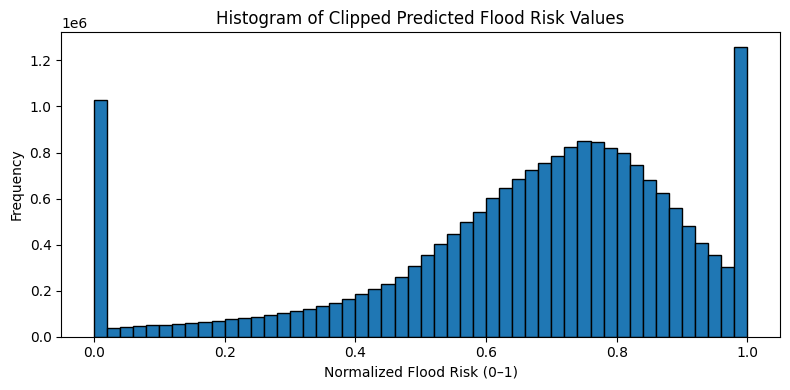

In [61]:
import matplotlib.pyplot as plt

# Flatten the array
flat = pred_clipped.ravel()

# Plot histogram
plt.figure(figsize=(8, 4))
plt.hist(flat, bins=50, edgecolor='black')
plt.xlabel('Normalized Flood Risk (0–1)')
plt.ylabel('Frequency')
plt.title('Histogram of Clipped Predicted Flood Risk Values')
plt.tight_layout()
plt.show()


In [45]:
import numpy as np
import matplotlib.pyplot as plt
import ipywidgets as widgets
from IPython.display import display

# Assume `pred_volume_test` is your predicted flood-risk array of shape (H, W, T)
# Example shape: (78, 110, 11568)
H, W, T = pred_clipped.shape

# Determine consistent color scale
vmin, vmax = pred_clipped.min(), pred_clipped.max()

def show_frame(t):
    """Plot a single time slice of the prediction volume."""
    plt.figure(figsize=(6, 5))
    img = plt.imshow(pred_clipped[:, :, t], vmin=vmin, vmax=vmax, cmap='viridis')
    plt.title(f'Predicted Flood Risk at Hour Index {t}')
    plt.xlabel('Grid X')
    plt.ylabel('Grid Y')
    plt.colorbar(img, label='Risk')
    plt.tight_layout()
    plt.show()

# Create an interactive slider for time
slider = widgets.IntSlider(
    value=0,
    min=0,
    max=T - 1,
    step=1,
    description='Time Index:',
    continuous_update=False,
    layout=widgets.Layout(width='80%')
)

# Link the slider to the plotting function
widgets.interact(show_frame, t=slider)


interactive(children=(IntSlider(value=0, continuous_update=False, description='Time Index:', layout=Layout(wid…

<function __main__.show_frame(t)>

In [122]:
import numpy as np
import torch

def predict_single_frame_scaled(frame_np, model, normalizer, device):
    """
    Predict and robust-scale a single frame.
    
    Args:
      frame_np: np.ndarray, shape (H, W, T_in, C)
      model: trained ConvLSTMForecast in eval() mode
      normalizer: ChannelNormalizer
      device: torch.device
      p_low: float, 5th percentile threshold
      p_high: float, 95th percentile threshold
      
    Returns:
      np.ndarray of shape (H, W, 1, 1) with values clipped to [0,1]
    """
    # 1. To tensor & permute (T_in, C, H, W)
    x = torch.from_numpy(frame_np).float().permute(2, 3, 0, 1)
    # 2. Normalize
    x = normalizer(x)
    # 3. Batch dim: (1, T_in, C, H, W)
    x = x.unsqueeze(0).to(device)
    
    # 4. Inference
    with torch.no_grad():
        pred = model(x)  # (1,1,H,W)
    pred_np = pred.squeeze().cpu().numpy()  # (H, W)
    min_val = pred_np.min()
    if min_val < 0:
        pred_np = pred_np - min_val
    clipped = np.clip(pred_np, 0, 1)
    return clipped




In [125]:
# Example usage:
k = 1
low_bound, high_bound = 1, 99
result = predict_single_frame_scaled(grid_data[:,:,11500:11568,:], model, normalizer, device, low_bound, high_bound, k)
print(result.shape)  # (78, 110)

(78, 110)


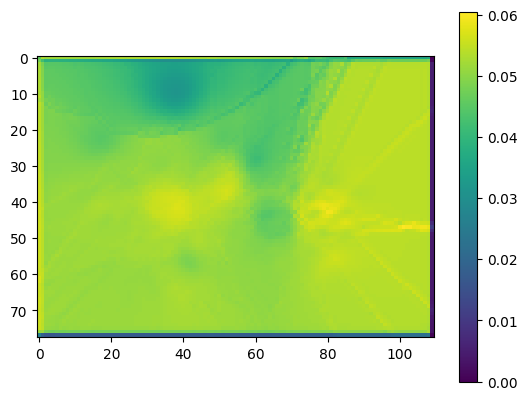

In [126]:
plt.imshow(result)
plt.colorbar()
plt.show()